In [17]:
import os
import operator
from typing import Annotated, List, Union, Literal
from dotenv import load_dotenv

# --- LangChain & OpenAI ---
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.tools import tool
from langchain_core.pydantic_v1 import BaseModel, Field 

# --- RAG & Almacenamiento ---
from langchain_chroma import Chroma
from langchain_community.document_loaders import DirectoryLoader, UnstructuredMarkdownLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain.chains import create_retrieval_chain
from langchain.chains.combine_documents import create_stuff_documents_chain
from langchain.agents import AgentExecutor, create_tool_calling_agent

# --- Orquestación (LangGraph) ---
from langgraph.graph import StateGraph, END

# --- Observabilidad & Visualización ---
from langfuse.callback import CallbackHandler
from IPython.display import Image, display

# --- Cargar entorno ---
load_dotenv()

# --- Configuración Global (Constants) ---
CHROMA_PATH = "chroma_db"
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

### Iniciamos LangFuse

In [18]:
# Inicializamos el handler con las credenciales de tu .env
langfuse_handler = CallbackHandler(
    public_key=os.getenv("LANGFUSE_PUBLIC_KEY"),
    secret_key=os.getenv("LANGFUSE_SECRET_KEY"),
    host=os.getenv("LANGFUSE_HOST")
)

# Prueba rápida de conexión
if langfuse_handler.auth_check():
    print("✅ Conexión con Langfuse exitosa. ¡Estamos trazando!")
else:
    print("❌ Error de conexión. Revisa tus API Keys.")

✅ Conexión con Langfuse exitosa. ¡Estamos trazando!


In [4]:
def create_vector_store(domain_name):
    print(f"--- Procesando dominio: {domain_name} ---")
    
    # 1. Cargar documentos
    loader = DirectoryLoader(
        f"./data/{domain_name}_docs", 
        glob="**/*.md", 
        loader_cls=UnstructuredMarkdownLoader
    )
    docs = loader.load()
    print(f"Documentos cargados: {len(docs)}")

    # 2. Dividir en fragmentos (Chunks)
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=1000,
        chunk_overlap=200,
        add_start_index=True
    )
    chunks = text_splitter.split_documents(docs)
    print(f"Fragmentos creados: {len(chunks)}")

    # 3. Guardar en ChromaDB (una colección por dominio)
    vector_store = Chroma.from_documents(
        documents=chunks,
        embedding=embeddings,
        persist_directory=CHROMA_PATH,
        collection_name=f"{domain_name}_collection"
    )
    
    print(f"✅ Dominio {domain_name} indexado correctamente.\n")
    return vector_store

# Ejecutamos la creación para nuestros 3 dominios
booking_db = create_vector_store("booking")
logistics_db = create_vector_store("logistics")
marketing_db = create_vector_store("marketing")

--- Procesando dominio: booking ---
Documentos cargados: 10
Fragmentos creados: 28
✅ Dominio booking indexado correctamente.

--- Procesando dominio: logistics ---
Documentos cargados: 10
Fragmentos creados: 47
✅ Dominio logistics indexado correctamente.

--- Procesando dominio: marketing ---
Documentos cargados: 10
Fragmentos creados: 56
✅ Dominio marketing indexado correctamente.



## Definimos TOOLS

#### Calculadora de Nafta y Clima

In [19]:
from langchain_core.tools import tool

@tool
def calculate_travel_costs(distance_km: float, consumption_per_100km: float = 10.0, fuel_price: float = 1100.0):
    """
    Calcula el costo estimado de combustible para un viaje.
    distance_km: Distancia total del viaje en kilómetros.
    consumption_per_100km: Litros que consume el vehículo cada 100km (defecto 10.0 para una Partner/Kangoo).
    fuel_price: Precio actual del litro de nafta en Argentina.
    """
    liters_needed = (distance_km / 100) * consumption_per_100km
    total_cost = liters_needed * fuel_price
    
    return {
        "liters_needed": round(liters_needed, 2),
        "estimated_cost_ars": round(total_cost, 2),
        "notes": "Cálculo basado en consumo promedio y precios actuales."
    }

@tool
def get_weather_forecast(city: str):
    """Simula el pronóstico del tiempo para una ciudad."""
    # Aquí voy a conectar una API real como OpenWeatherMap en el futuro
    return f"El pronóstico para {city} es de 24°C, despejado. Ideal para cargar instrumentos o tocar al aire libre."

## EL ORQUESTADOR (ROUTER)

In [20]:
from pydantic import BaseModel, Field
from typing import Literal
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

# 1. Definición del Esquema de Salida (Contrato de Datos)
class RouteQuery(BaseModel):
    """Ruta la consulta del usuario al experto más adecuado basándose en el dominio."""
    topic: Literal["booking", "logistics", "marketing", "weather"] = Field(
        description="El dominio experto para la consulta: booking, logistics, marketing o weather."
    )

# 2. Configuración del LLM y el Router Estructurado
# Usamos temperature 0 para máxima consistencia en la clasificación
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
structured_llm_router = llm.with_structured_output(RouteQuery)

# 3. Prompt de Sistema (Instrucciones de Razonamiento)
system_prompt = """Eres el Tour Manager Senior de BeatSync. 
Tu función es clasificar las consultas de los artistas en uno de los siguientes departamentos:

1. BOOKING: Bares, locales, centros culturales, festivales, disponibilidad de fechas o cachets.
2. LOGISTICS: Rutas, distancias, cálculos de nafta/consumo y hoteles con cochera segura.
3. MARKETING: Gacetillas de prensa, promoción en redes, mensajes para radios y planes de difusión.
4. WEATHER: Clima, pronóstico meteorológico y condiciones para eventos al aire libre.

Analiza cuidadosamente la intención del usuario y responde ÚNICAMENTE con el tópico en formato JSON."""

route_prompt = ChatPromptTemplate.from_messages([
    ("system", system_prompt),
    ("human", "{question}"),
])

# 4. Creación de la Cadena (Chain)
question_router = route_prompt | structured_llm_router

## RAG Chain + Agent con Tools

In [21]:
from langchain.chains import create_retrieval_chain
from langchain.chains.combine_documents import create_stuff_documents_chain
from langchain.agents import AgentExecutor, create_tool_calling_agent
from langchain_core.prompts import MessagesPlaceholder

# --- Función para agentes RAG puros (Booking, Marketing) ---
def create_rag_chain(db, system_instruction):
    agent_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.2)
    retriever = db.as_retriever(search_kwargs={"k": 3})
    
    prompt = ChatPromptTemplate.from_messages([
        ("system", system_instruction + "\n\nContexto extraído:\n{context}"),
        ("human", "{input}"),
    ])
    
    combine_docs_chain = create_stuff_documents_chain(agent_llm, prompt)
    return create_retrieval_chain(retriever, combine_docs_chain)

# --- Función para agente con Tools (Logística) ---
def create_agent_with_tools(db, system_instruction, tools):
    agent_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.2)
    
    prompt = ChatPromptTemplate.from_messages([
        ("system", system_instruction + "\nTienes acceso a herramientas especializadas. Úsalas cuando sea apropiado."),
        ("human", "{input}"),
        MessagesPlaceholder(variable_name="agent_scratchpad"),
    ])
    
    agent = create_tool_calling_agent(agent_llm, tools, prompt)
    return AgentExecutor(agent=agent, tools=tools, verbose=True)

# --- INSTRUCCIONES DE PERSONALIDAD ---
booking_instruction = "Eres el Agente de Booking de TourMaster. Tu meta es encontrar los mejores bares y fechas. Sé profesional y directo."
logistics_instruction = "Eres el Experto en Logística de TourMaster. Ayuda a bandas con rutas, cálculos de combustible y hospedajes con cochera. Cuando te pregunten por costos de viaje o nafta, USA SIEMPRE la herramienta calculate_travel_costs."
marketing_instruction = "Eres el Gurú de Marketing Musical. Crea gacetillas de prensa y planes de redes sociales que emocionen."

# --- CREACIÓN DE LOS AGENTES ---
booking_agent = create_rag_chain(booking_db, booking_instruction)
logistics_agent = create_agent_with_tools(logistics_db, logistics_instruction, tools=[calculate_travel_costs])
marketing_agent = create_rag_chain(marketing_db, marketing_instruction)

print("✅ Agentes creados correctamente")
print("   - Booking: RAG Chain")
print("   - Logistics: Agent con Tools (calculate_travel_costs)")
print("   - Marketing: RAG Chain")

✅ Agentes creados correctamente
   - Booking: RAG Chain
   - Logistics: Agent con Tools (calculate_travel_costs)
   - Marketing: RAG Chain


#### Creamos una función para guardar el estado e historial de mensajes

In [22]:
from typing import TypedDict, Annotated, List, Union
import operator

class AgentState(TypedDict):
    messages: Annotated[List[dict], operator.add]
    next_node: str
    query: str
    answer: str
    expert_used: str

### Creamos los NODOS

In [23]:
def orchestrator_node(state: AgentState):
    res = question_router.invoke({"question": state["query"]})
    chosen_topic = res.topic.lower()
    print(f"🧠 [ORQUESTADOR]: Clasificando como experto en {chosen_topic.upper()}")
    return {
        "next_node": chosen_topic,
        "expert_used": chosen_topic.upper()
    }

def booking_node(state: AgentState):
    res = booking_agent.invoke({"input": state["query"]})
    return {"answer": res["answer"], "expert_used": "BOOKING"}

def logistics_node(state: AgentState):
    # AgentExecutor utiliza la llave 'output'
    res = logistics_agent.invoke({"input": state["query"]})
    return {"answer": res["output"], "expert_used": "LOGISTICS"}

def marketing_node(state: AgentState):
    res = marketing_agent.invoke({"input": state["query"]})
    return {"answer": res["answer"], "expert_used": "MARKETING"}

def weather_node(state: AgentState):
    llm_weather = ChatOpenAI(model="gpt-4o-mini").bind_tools([get_weather_forecast])
    res = llm_weather.invoke(state["query"])
    
    if res.tool_calls:
        forecast = get_weather_forecast.invoke(res.tool_calls[0]["args"])
        return {"answer": f"Pronóstico: {forecast}", "expert_used": "WEATHER"}
    
    return {"answer": res.content, "expert_used": "WEATHER"}

### Definimos el EVALUATOR

In [25]:
from pydantic import BaseModel, Field

class EvaluationScore(BaseModel):
    """Puntaje de calidad de la respuesta de la IA."""
    score: int = Field(description="Puntaje del 1 al 10")
    reason: str = Field(description="Breve explicación del porqué del puntaje")

# LLM estructurado para el evaluador
evaluator_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0).with_structured_output(EvaluationScore)

def evaluator_node(state: AgentState):
    """Evalúa la calidad de la respuesta generada."""
    query = state["query"]
    answer = state["answer"]
    
    eval_prompt = f"""
    Eres un auditor de calidad de IA. 
    Evalúa la siguiente respuesta basándote en la consulta original.
    
    CONSULTA: {query}
    RESPUESTA GENERADA: {answer}
    
    Debes puntuar del 1 al 10 basándote en:
    - Precisión: ¿Responde lo que se pidió?
    - Fundamentación: ¿Se nota que usó datos (bares, hoteles, cálculos)?
    - Tono: ¿Es profesional y útil?
    """
    
    evaluation = evaluator_llm.invoke(eval_prompt)
    
    # IMPORTANTE: Aquí enviamos el puntaje a Langfuse de forma manual
    # Usamos el handler para obtener la traza actual
    langfuse_handler.langfuse.score(
        name="answer-quality",  
        value=evaluation.score,
        comment=evaluation.reason
    )
    
    print(f"⚗️ Evaluación: {evaluation.score}/10 - {evaluation.reason}")
    return {"messages": [("ai", f"Calidad: {evaluation.score}/10")]}

## Contrucción del GRÁFICO 
 Se utiliza Conditional Edge, (Enrutamiento condicional) para el Orquestador elija al agente experto que crea conveniente.
 Importamos StateGraph de LangGraph

In [27]:
from langgraph.graph import StateGraph, END

workflow = StateGraph(AgentState)

# 1. Agregar todos los nodos
workflow.add_node("orchestrator", orchestrator_node)
workflow.add_node("booking", booking_node)
workflow.add_node("logistics", logistics_node)
workflow.add_node("marketing", marketing_node)
workflow.add_node("weather", weather_node) 
workflow.add_node("evaluator", evaluator_node) 

# 2. Configurar punto de entrada
workflow.set_entry_point("orchestrator")

# 3. Enrutamiento Condicional (El Orquestador decide)
workflow.add_conditional_edges(
    "orchestrator",
    lambda state: state["next_node"],
    {
        "booking": "booking",
        "logistics": "logistics",
        "marketing": "marketing",
        "weather": "weather"    
    }
)

# 4. Los expertos NO terminan, ahora pasan por Control de Calidad
workflow.add_edge("booking", "evaluator")
workflow.add_edge("logistics", "evaluator")
workflow.add_edge("marketing", "evaluator")
workflow.add_edge("weather", "evaluator")

# 5. El Evaluador es el último paso
workflow.add_edge("evaluator", END)

# 6. Compilar
app = workflow.compile()
print("✅ Grafo de TourMaster compilado correctamente")

✅ Grafo de TourMaster compilado correctamente


#### Codigo para VER el GRAFO

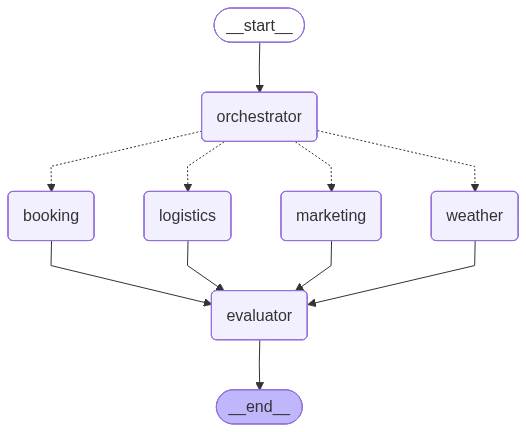

In [28]:
from IPython.display import Image, display

try:
    # Genera el diagrama usando Mermaid (formato estándar de grafos)
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    # Si falta alguna librería de dibujo, nos da una versión en texto (ASCII)
    print(app.get_graph().print_ascii())

## Función para ejecutar todo el sistema

In [29]:
def run_tourmaster_graph(query: str):
    """
    Punto de entrada principal para el sistema TourMaster.
    Carga el estado inicial y ejecuta el grafo compilado.
    """
    # Estado inicial del flujo
    inputs = {
        "query": query, 
        "messages": []
    }
    
    # Ejecución con trazabilidad de Langfuse
    config = {"callbacks": [langfuse_handler]}
    final_state = app.invoke(inputs, config=config)
    
    # Formateo de salida para la consola
    expert = final_state.get('expert_used', 'DESCONOCIDO')
    
    print(f"\n{'='*70}")
    print(f"💡 TOURMASTER AI - RESPUESTA DEL EXPERTO EN {expert}")
    print(f"{'='*70}")
    print(f"Pregunta: {query}")
    print(f"\nRespuesta:\n{final_state['answer']}")
    print(f"{'='*70}\n")
    
    return final_state

In [31]:
print(run_tourmaster_graph("Que clima habrá en Rosario el fin de semana que viene?"))

🧠 [ORQUESTADOR]: Clasificando como experto en WEATHER
⚗️ Evaluación: 6/10 - La respuesta proporciona un pronóstico de clima, pero no menciona la fecha específica del fin de semana que viene, lo que afecta la precisión. Además, no se fundamenta en datos concretos ni se menciona la fuente del pronóstico. El tono es amigable y útil, pero podría ser más profesional.

💡 TOURMASTER AI - RESPUESTA DEL EXPERTO EN WEATHER
Pregunta: Que clima habrá en Rosario el fin de semana que viene?

Respuesta:
Pronóstico: El pronóstico para Rosario es de 24°C, despejado. Ideal para cargar instrumentos o tocar al aire libre.

{'messages': [('ai', 'Calidad: 6/10')], 'next_node': 'weather', 'query': 'Que clima habrá en Rosario el fin de semana que viene?', 'answer': 'Pronóstico: El pronóstico para Rosario es de 24°C, despejado. Ideal para cargar instrumentos o tocar al aire libre.', 'expert_used': 'WEATHER'}


### Preguntas picantes para testear

In [15]:
# Definimos los escenarios de prueba
spicy_tests = [
    # 1. Prueba de Lógica y Tool: Obliga al agente de Logística a calcular y usar RAG.
    "Somos una banda de 5 personas en una Partner. Vamos de Córdoba a Rosario. ¿Cuánto gastamos de nafta y qué hotel con cochera nos recomiendas allá?",
    
    # 2. Prueba de Matiz: El orquestador debe elegir entre Marketing o Weather.
    "Tengo que subir un post a Instagram avisando que el show de mañana se hace igual aunque llueva. ¿Me armás el texto?",
    
    # 3. Prueba de Datos RAG: Busca capacidad específica en una ciudad específica.
    "Buscamos un lugar en Buenos Aires para presentar el disco, tiene que ser para más de 200 personas y de género Rock. ¿Qué opciones hay?"

    # 4. Prueba de Weather Agent
    "¿Cómo va a estar el tiempo en Búzios mañana? Queremos saber si podemos tocar al aire libre."
]

print("🚀 Iniciando Suite de Pruebas de TourMaster AI...\n")

for i, test_query in enumerate(spicy_tests):
    print(f"Ejecutando Test #{i+1}...")
    try:
        run_tourmaster_graph(test_query)
    except Exception as e:
        print(f"❌ Error en Test #{i+1}: {e}")

print("\n✅ Suite de pruebas finalizada. Revisa Langfuse para ver los puntajes del Evaluador.")

🚀 Iniciando Suite de Pruebas de TourMaster AI...

Ejecutando Test #1...
🧠 [ORQUESTADOR]: Clasificando como experto en LOGISTICS


> Entering new AgentExecutor chain...

Invoking: `calculate_travel_costs` with `{'distance_km': 400}`


{'liters_needed': 40.0, 'estimated_cost_ars': 44000.0, 'notes': 'Cálculo basado en consumo promedio y precios actuales.'}El viaje de Córdoba a Rosario, que es de aproximadamente 400 km, te costará alrededor de **44,000 ARS** en combustible, asumiendo un consumo promedio de 10 litros cada 100 km.

En cuanto a hospedaje, te recomiendo el **Hotel Ros Tower**, que cuenta con cochera y es muy bien valorado por su comodidad y servicios. Otra opción es el **Hotel Solans Riviera**, que también ofrece cochera y está bien ubicado. 

Si necesitas más información o ayuda con la ruta, ¡no dudes en preguntar!

> Finished chain.
⭐ Evaluación: 8/10 - La respuesta es precisa en cuanto al costo estimado de combustible y sugiere hoteles con cochera, lo cual es relevante. Sin